# SSD Parking Space Detection

This notebook fine-tunes SSD Lite 320 MobileNetV3 for parking space detection using the YOLO-formatted dataset.

Features:
- Fine-tunes SSD Lite 320 MobileNetV3 on 3 classes (free, not_free, partially_free parking spaces)
- Uses existing YOLO-formatted dataset at `data/processed/yolo_parking/`
- Checkpoint saving (best model + periodic checkpoints)
- Early stopping mechanism
- Resume functionality - continue training from checkpoints
- Training and validation loss visualization
- Sample prediction visualization



## 1. Imports & Path Setup



In [86]:
import os
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt
import random

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.transforms.functional import convert_image_dtype

from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights
from torchvision.models import MobileNet_V3_Large_Weights

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == "Phase 1" else (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
YOLO_ROOT = BASE_DIR / "data" / "processed" / "yolo_parking"

IMG_TRAIN = YOLO_ROOT / "images" / "train"
IMG_VAL = YOLO_ROOT / "images" / "val"
LBL_TRAIN = YOLO_ROOT / "labels" / "train"
LBL_VAL = YOLO_ROOT / "labels" / "val"

# Checkpoint directory
CHECKPOINT_DIR = BASE_DIR / "checkpoints" / "ssd_parking"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("YOLO_ROOT exists:", YOLO_ROOT.exists())
print("Train images dir:", IMG_TRAIN, IMG_TRAIN.exists())
print("Train labels dir:", LBL_TRAIN, LBL_TRAIN.exists())
print("Checkpoint dir:", CHECKPOINT_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



BASE_DIR: c:\Harosha\George Brown\DL2\parking-vision
YOLO_ROOT exists: True
Train images dir: c:\Harosha\George Brown\DL2\parking-vision\data\processed\yolo_parking\images\train True
Train labels dir: c:\Harosha\George Brown\DL2\parking-vision\data\processed\yolo_parking\labels\train True
Checkpoint dir: c:\Harosha\George Brown\DL2\parking-vision\checkpoints\ssd_parking
Using device: cpu


## 2. Class Names & Label Mapping

**Important**: YOLO uses class IDs 0, 1, 2, but SSD expects class IDs 1, 2, 3 (0 is background class).



In [87]:
# YOLO-style class names from data.yaml
class_names = [
    "free_parking_space",
    "not_free_parking_space",
    "partially_free_parking_space",
]

num_classes_without_bg = len(class_names)
num_classes_with_bg = num_classes_without_bg + 1  # SSD includes background as class 0

print("Classes (no bg):", class_names)
print("num_classes_with_bg (for SSD):", num_classes_with_bg)

# Mapping YOLO class_id -> SSD class_id
# YOLO 0,1,2 -> SSD 1,2,3 (0 is background)
yolo_to_ssd = {0: 1, 1: 2, 2: 3}

print("\nLabel mapping:")
print("YOLO class 0 -> SSD class 1 (free_parking_space)")
print("YOLO class 1 -> SSD class 2 (not_free_parking_space)")
print("YOLO class 2 -> SSD class 3 (partially_free_parking_space)")



Classes (no bg): ['free_parking_space', 'not_free_parking_space', 'partially_free_parking_space']
num_classes_with_bg (for SSD): 4

Label mapping:
YOLO class 0 -> SSD class 1 (free_parking_space)
YOLO class 1 -> SSD class 2 (not_free_parking_space)
YOLO class 2 -> SSD class 3 (partially_free_parking_space)


## 3. Custom Dataset for YOLO -> SSD

Converts YOLO format annotations to SSD format (bounding boxes in pixel coordinates).



In [88]:
class YoloDetectionDataset(Dataset):
    def __init__(self, img_dir: Path, lbl_dir: Path, yolo_to_ssd_map: dict):
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.yolo_to_ssd = yolo_to_ssd_map

        # collect all image files
        exts = (".jpg", ".jpeg", ".png")
        self.img_paths = [p for p in sorted(img_dir.rglob("*")) if p.suffix.lower() in exts]

        if len(self.img_paths) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        # labels file same stem, .txt
        lbl_path = self.lbl_dir / (img_path.stem + ".txt")

        # read image [C,H,W] in uint8, convert to float [0,1]
        img = read_image(str(img_path))  # shape: (C,H,W) - could be 1, 3, or 4 channels
        
        # Handle different channel counts
        C, H, W = img.shape
        if C == 1:
            # Grayscale - convert to RGB by repeating channels
            img = img.repeat(3, 1, 1)
        elif C == 4:
            # RGBA - drop alpha channel, keep RGB
            img = img[:3, :, :]
        elif C != 3:
            # Unexpected channel count
            raise ValueError(f"Unexpected number of channels: {C} for image {img_path}")
        
        img = convert_image_dtype(img, dtype=torch.float32)

        _, H, W = img.shape

        boxes = []
        labels = []

        if lbl_path.exists():
            with open(lbl_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_yolo = int(parts[0])
                    xc_n, yc_n, w_n, h_n = map(float, parts[1:])

                    # convert YOLO normalized to pixel coords
                    xc = xc_n * W
                    yc = yc_n * H
                    bw = w_n * W
                    bh = h_n * H

                    x_min = xc - bw / 2.0
                    y_min = yc - bh / 2.0
                    x_max = xc + bw / 2.0
                    y_max = yc + bh / 2.0

                    # clip to image bounds
                    x_min = max(0.0, x_min)
                    y_min = max(0.0, y_min)
                    x_max = min(float(W), x_max)
                    y_max = min(float(H), y_max)

                    if x_max <= x_min or y_max <= y_min:
                        continue

                    # remap class id for SSD
                    if cls_yolo not in self.yolo_to_ssd:
                        continue
                    cls_ssd = self.yolo_to_ssd[cls_yolo]

                    boxes.append([x_min, y_min, x_max, y_max])
                    labels.append(cls_ssd)

        if len(boxes) == 0:
            # if no boxes, create empty target
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
        }

        return img, target

train_dataset = YoloDetectionDataset(IMG_TRAIN, LBL_TRAIN, yolo_to_ssd)
val_dataset = YoloDetectionDataset(IMG_VAL, LBL_VAL, yolo_to_ssd)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))



Train samples: 24
Val samples: 6


In [89]:
def detection_collate_fn(batch):
    images = []
    targets = []
    for img, tgt in batch:
        images.append(img)
        targets.append(tgt)
    return images, targets

BATCH_SIZE = 8

# Note: num_workers=0 on Windows to avoid multiprocessing issues
# Set to 2-4 on Linux/Mac for faster data loading
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Windows compatibility - use 0, set to 2-4 on Linux/Mac
    collate_fn=detection_collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Windows compatibility - use 0, set to 2-4 on Linux/Mac
    collate_fn=detection_collate_fn,
)

# quick sanity check
imgs, tgts = next(iter(train_loader))
print("Batch len:", len(imgs), "Image shape:", imgs[0].shape)
print("Targets sample - boxes shape:", tgts[0]["boxes"].shape, "labels:", tgts[0]["labels"])



Batch len: 8 Image shape: torch.Size([3, 566, 1000])
Targets sample - boxes shape: torch.Size([20, 4]) labels: tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2])


## 4. Load SSD Model (Pretrained) & Configure Training

We'll use ssdlite320_mobilenet_v3_large from torchvision.models.detection.

**Important**: `num_classes` must include background (so 4 total: background + 3 parking classes).



In [90]:
# Load SSD model with pretrained backbone weights
# Note: We can't use full pretrained weights (weights=SSDLite320_MobileNet_V3_Large_Weights.DEFAULT)
# because they expect 91 classes (COCO). Instead, we load without full weights and use
# weights_backbone to load just the MobileNetV3 backbone weights.
ssd_model = ssdlite320_mobilenet_v3_large(
    weights=None,  # No full model weights (would be 91 classes)
    num_classes=num_classes_with_bg,  # 4 = 3 classes + background
    weights_backbone=MobileNet_V3_Large_Weights.DEFAULT,  # Load pretrained MobileNetV3 backbone
).to(device)

# put model in training mode
ssd_model.train()

# Setup optimizer
params = [p for p in ssd_model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=1e-4)

print("SSD Model loaded and configured")
print(f"Total parameters: {sum(p.numel() for p in ssd_model.parameters() if p.requires_grad):,}")



SSD Model loaded and configured
Total parameters: 3,742,160


## 5. Training Configuration

Configure training parameters including epochs, early stopping, and checkpoint settings.



In [91]:
# Training hyperparameters
NUM_EPOCHS = 1000
EARLY_STOPPING_PATIENCE = 50  # Stop if no improvement for this many epochs
MIN_DELTA = 0.001  # Minimum change to qualify as improvement
CHECKPOINT_EVERY = 50  # Save checkpoint every N epochs

print("Training Configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Early Stopping Patience: {EARLY_STOPPING_PATIENCE} epochs")
print(f"  Min Delta: {MIN_DELTA}")
print(f"  Checkpoint Every: {CHECKPOINT_EVERY} epochs")



Training Configuration:
  Epochs: 1000
  Early Stopping Patience: 50 epochs
  Min Delta: 0.001
  Checkpoint Every: 50 epochs


### 6.1 Optional: Reset Checkpoints (Start Fresh)

Run this cell only if you want to delete all checkpoints and start training from scratch.



In [92]:
# Uncomment the lines below to delete all checkpoints and start fresh
# import shutil
# if CHECKPOINT_DIR.exists():
#     for checkpoint_file in CHECKPOINT_DIR.glob("*.pt"):
#         checkpoint_file.unlink()
#         print(f"Deleted: {checkpoint_file.name}")
#     print("All checkpoints deleted. Training will start from scratch.")
# else:
#     print("No checkpoints directory found.")




Checkpoint reset is disabled. Uncomment the code above to enable.


## 6. Training Functions

Functions for training one epoch and evaluating the model.



In [93]:
def train_one_epoch_ssd(model, data_loader, optimizer, device):
    model.train()
    running_loss = 0.0
    num_batches = 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()
        num_batches += 1

    return running_loss / max(1, num_batches)

@torch.no_grad()
def evaluate_ssd(model, data_loader, device):
    # Keep model in training mode to get losses (not predictions)
    # but use no_grad() to prevent gradient computation
    model.train()
    running_loss = 0.0
    num_batches = 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        running_loss += losses.item()
        num_batches += 1

    return running_loss / max(1, num_batches)

print("Training functions defined")



Training functions defined


## 7. Training Loop with Early Stopping, Checkpoints, and Resume

**Resume Functionality**: If a checkpoint exists, training will automatically resume from the last saved epoch. Simply increase `NUM_EPOCHS` to continue training beyond the checkpoint. To start fresh, delete the checkpoint files.



In [94]:
# Initialize training state
start_epoch = 1
best_val_loss = float("inf")
history = {
    "train_loss": [],
    "val_loss": [],
}
patience_counter = 0
best_epoch = 0

# Try to load the best model checkpoint first (most recent training)
best_model_path = CHECKPOINT_DIR / "best_model.pt"
if best_model_path.exists():
    print(f"Found existing checkpoint: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    
    # Load model state
    ssd_model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Restore training state
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', checkpoint.get('val_loss', float('inf')))
    best_epoch = checkpoint.get('best_epoch', checkpoint['epoch'])
    history = checkpoint.get('history', history)
    patience_counter = checkpoint.get('patience_counter', 0)
    
    print(f"Resuming training from epoch {start_epoch}")
    print(f"Previous best: Val Loss = {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"Previous history: {len(history['train_loss'])} epochs completed")
    
    # If we're already past NUM_EPOCHS, inform user
    if start_epoch > NUM_EPOCHS:
        print(f"\nNote: Checkpoint is at epoch {start_epoch-1}, but NUM_EPOCHS={NUM_EPOCHS}.")
        print("Increase NUM_EPOCHS to continue training beyond the checkpoint.")
else:
    print("No existing checkpoint found. Starting fresh training.")

start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    train_loss = train_one_epoch_ssd(ssd_model, train_loader, optimizer, device)
    val_loss = evaluate_ssd(ssd_model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Check for improvement
    improved = False
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        improved = True
        
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': ssd_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
            'best_epoch': best_epoch,
            'patience_counter': patience_counter,
            'history': history,
        }, best_model_path)
        print(f"  -> New best model saved! (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1

    # Save periodic checkpoint
    if epoch % CHECKPOINT_EVERY == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': ssd_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'history': history,
            'best_epoch': best_epoch,
        }, checkpoint_path)
        print(f"  -> Checkpoint saved: {checkpoint_path.name}")

    print(f"Epoch [{epoch}/{NUM_EPOCHS}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}{' *' if improved else ''}")

    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered! No improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
        break

end_time = time.time()
print(f"\nTraining finished in {(end_time - start_time)/60:.2f} minutes.")
print(f"Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")



Found existing checkpoint: c:\Harosha\George Brown\DL2\parking-vision\checkpoints\ssd_parking\best_model.pt


C:\Users\haros\AppData\Local\Temp\ipykernel_40664\94486737.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device)

Resuming training from epoch 131
Previous best: Val Loss = 4.9475 at epoch 130
Previous history: 130 epochs completed
Epoch [131/1000] Train Loss: 1.1906 | Val Loss: 4.9486
Epoch [132/1000] Train Loss: 1.2057 | Val Loss: 4.9475
Epoch [133/1000] Train Loss: 1.2399 | Val Loss: 4.9495
Epoch [134/1000] Train Loss: 1.1501 | Val Loss: 4.9573
Epoch [135/1000] Train Loss: 1.2594 | Val Loss: 4.9672
Epoch [136/1000] Train Loss: 1.1426 | Val Loss: 4.9800
Epoch [137/1000] Train Loss: 1.1908 | Val Loss: 4.9823
Epoch [138/1000] Train Loss: 1.2161 | Val Loss: 4.9818
Epoch [139/1000] Train Loss: 1.2061 | Val Loss: 4.9710
Epoch [140/1000] Train Loss: 1.0789 | Val Loss: 4.9677
Epoch [141/1000] Train Loss: 1.0292 | Val Loss: 4.9692
Epoch [142/1000] Train Loss: 1.0531 | Val Loss: 4.9781
Epoch [143/1000] Train Loss: 1.0322 | Val Loss: 4.9797
Epoch [144/1000] Train Loss: 1.0495 | Val Loss: 4.9759
Epoch [145/1000] Train Loss: 1.0497 | Val Loss: 4.9723
Epoch [146/1000] Train Loss: 1.0147 | Val Loss: 4.9682
Ep

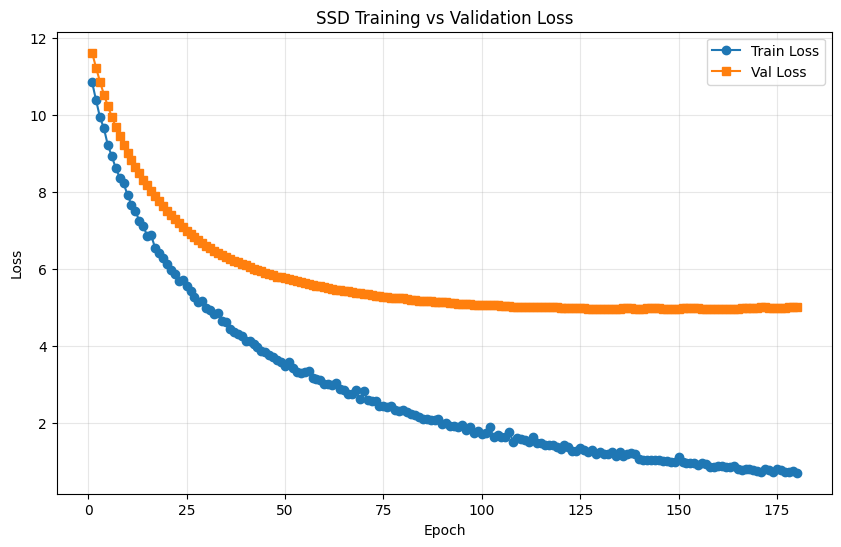

Final train loss: 0.7105
Final val loss: 5.0049
Best val loss: 4.9475 at epoch 130


In [95]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs, history["val_loss"], label="Val Loss", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SSD Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss: {history['val_loss'][-1]:.4f}")
print(f"Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")



## 8. Load Best Model & Run Inference on Validation Images

Load the best model and visualize predictions on a few validation images.



In [96]:
# Reload best weights
best_ssd_model = ssdlite320_mobilenet_v3_large(
    weights=None,
    num_classes=num_classes_with_bg,
).to(device)

best_model_path = CHECKPOINT_DIR / "best_model.pt"
if best_model_path.exists():
    checkpoint = torch.load(best_model_path, map_location=device)
    best_ssd_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")
    print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
else:
    print("Warning: Best model checkpoint not found. Using current model state.")
    best_ssd_model.load_state_dict(ssd_model.state_dict())

best_ssd_model.eval()



C:\Users\haros\AppData\Local\Temp\ipykernel_40664\965309436.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device)

Loaded best model from epoch 130
Best validation loss: 4.9475


SSD(
  (backbone): SSDLiteFeatureExtractorMobileNet(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (2): Hardswish()
        )
        (1): InvertedResidual(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
              (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
            )
            (1): Conv2dNormActivation(
              (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
            )
          )
        )
        (2): Invert

### 10.1 Visualization Helper Function



In [97]:
def plot_predictions_ssd(model, dataset, num_images=3, score_thresh=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), k=min(num_images, len(dataset)))

    for idx in indices:
        img, _ = dataset[idx]
        img_gpu = img.to(device).unsqueeze(0)

        with torch.no_grad():
            outputs = model(img_gpu)[0]

        boxes = outputs["boxes"].cpu().numpy()
        labels = outputs["labels"].cpu().numpy()
        scores = outputs["scores"].cpu().numpy()

        # convert image to numpy for plotting
        img_np = img.cpu().numpy().transpose(1, 2, 0)  # [H,W,C]
        img_np = np.clip(img_np, 0, 1)

        plt.figure(figsize=(8, 8))
        plt.imshow(img_np)
        ax = plt.gca()

        for box, label, score in zip(boxes, labels, scores):
            if score < score_thresh:
                continue
            x1, y1, x2, y2 = box
            cls_idx = int(label.item()) - 1  # we stored classes as 1..3, map back to 0..2
            if cls_idx < 0 or cls_idx >= len(class_names):
                continue
            cls_name = class_names[cls_idx]

            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                 fill=False, color="lime", linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, y1-5,
                    f"{cls_name} {score:.2f}",
                    color="yellow",
                    fontsize=10,
                    bbox=dict(facecolor="black", alpha=0.5, pad=1))

        plt.axis("off")
        plt.title(f"SSD predictions (idx={idx}, threshold={score_thresh})")
        plt.show()

print("Visualization function defined")



Visualization function defined


### 10.2 Visualize Predictions



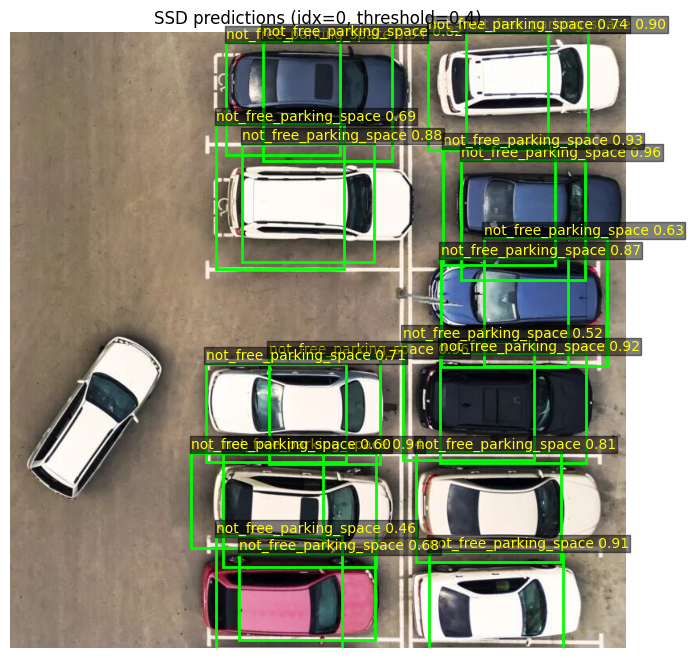

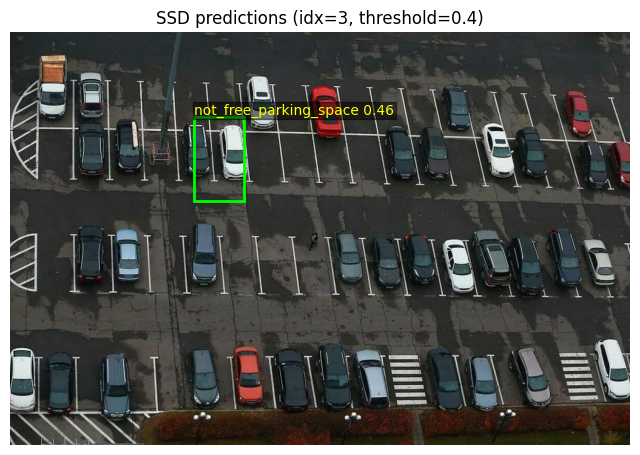

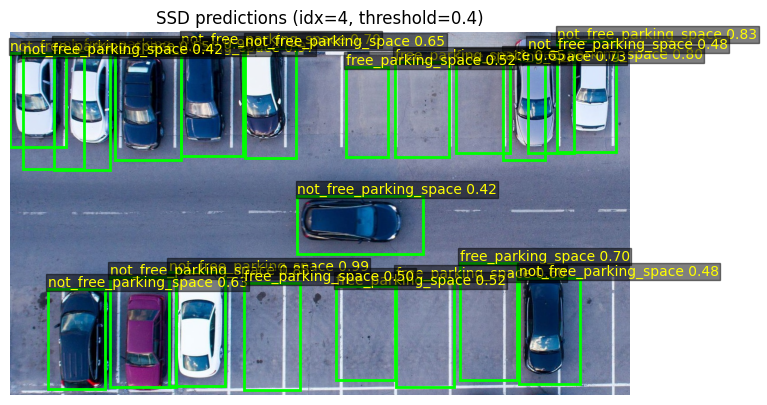

In [98]:
# Visualize predictions on validation images
plot_predictions_ssd(best_ssd_model, val_dataset, num_images=3, score_thresh=0.4)



## 9. (Optional) Rough FPS Measurement

Measure inference speed for comparison with YOLO.



In [99]:
@torch.no_grad()
def measure_fps(model, dataset, num_samples=50):
    model.eval()
    t0 = time.time()
    count = 0
    for i in range(num_samples):
        img, _ = dataset[i % len(dataset)]
        img_gpu = img.to(device).unsqueeze(0)
        outputs = model(img_gpu)
        count += 1
    t1 = time.time()
    fps = count / (t1 - t0)
    return fps

fps_ssd = measure_fps(best_ssd_model, val_dataset, num_samples=30)
print(f"Approx SSD FPS on {device}: {fps_ssd:.2f} frames/s")



Approx SSD FPS on cpu: 7.99 frames/s
